# **Q: Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment).**

**Import Libraries**

In [143]:
from dataclasses import replace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# **1. Identifying the Prediction Target**


The business objective of the campaign is to determine, before or during a call, which clients are likely to subscribe to a term deposit. This allows the bank to prioritise outreach to high-probability clients, reducing campaign costs, and to improve conversion rates by targeting the right customer segments.

The variable y directly encodes the outcome of interest, the target variable (for this assignment) is y. It is a binary variable that answers the question: "Has the client subscribed to a term deposit?" which means whether contact resulted in a subscription with possible values of (yes) or (no).

It satisfies every criterion for a valid prediction target:
- **Causal role:** it is the effect we want to predict, not a cause.
- **Tmporality**: it is observed after the campaign contact, making it a valid label for supervised learning.
- **Business-relevance:** predicting it enables actionable decisions before a call is made.
- **Clean and unambiguous:** a binary outcome with no sentinel values or encoding quirks. In the language of Lecture 1, this is a binary classification problem: we map a feature vector x (client and campaign attributes available at the time of contact) to a label y ∈ {no, yes}.
- **Measurability:** It is a clean, unambiguous binary outcome with no sentinel values. Accodring to Lecture 1, this is a **binary classification problem**: we map a feature vector $\mathbf{x}$ (client and campaign attributes available at the time of contact) to a label $y \in \{\text{no}, \text{yes}\}$.


#### **Variables that could superficially appear to be valid targets (not are not)**

Several variables in the dataset might initially seem like reasonable prediction targets but are not appropriate for this task.

1. `duration`: records how long the previous phone call lasted (in seconds).

It is strongly correlated with y. A call that ends quickly likely means the client declined, while a long call often leads to a subscription. One might be tempted to treat duration as a proxy or surrogate for y. However, duration is not known before the call is made. At prediction time, when we want to decide whether to call a client at all, this value simply does not yet exist. The dataset documentation explicitly warns that this variable should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. Using duration as a target, or even as a feature, constitutes target leakage: it carries information that is only available after the outcome has effectively been determined.

2. `poutcome`: records whether a prior campaign resulted in a success, failure, or nonexistent outcome (meaning no prior contact).

It is strongly predictive of y and might appear to be a valid target because it also captures campaign success. However, poutcome refers to a past event from a previous, different campaign, not the current one. It is historical information that is already known at prediction time. Treating it as the target would mean predicting something already observed, rather than future subscription behaviour, making the task trivial and commercially useless. It is also a three-class categorical variable, which does not map cleanly onto the binary classification objective defined by the bank.

3. `campaign` : number of contacts during this campaign

This counts how many times the client was contacted during the current campaign. It might seem like a target because it reflects the intensity of the bank's effort — and one could imagine wanting to predict "how many calls will it take?". However:
It's a campaign management variable, not a client outcome. The bank controls it; the client doesn't decide it.
It is partially observed during the campaign, meaning it accumulates as contacts happen — it's not a clean post-hoc label.
Predicting campaign would reframe the problem as a regression task about operational effort, completely ignoring whether the client actually subscribes.
Most critically, it carries no information about the success of the campaign from the client's perspective.

4. `pdays` : number of days since last contact from a previous campaign; 999 = never contacted

This might look like a target because 999 is a sentinel value that encodes a meaningful state ("never contacted before"), giving it a quasi-categorical feel. Someone might think: "predict whether this client is a new prospect or a returning one."
But:
pdays is historical metadata — it is fully known at the time of the call and describes the past, not the future.
Predicting it would mean predicting something the bank already knows before dialling. It has zero predictive utility as a target.
The 999 sentinel also makes it statistically unusual (heavily right-skewed with a mass point), which could make it look like it needs special treatment as a label — but this is a red herring. It's an input feature quirk, not a labelling problem.
The business has no interest in "predicting" how many days ago a client was last called — that's a lookup, not a prediction.


**Summary:**

y is the only column that satisfies all three requirements for a valid prediction target. It is the desired business outcome, it is not available at prediction time, and it is free of post-hoc information. Duration, poutcome, campaign, and pdays each fail at least one of these criteria, for reasons rooted in leakage, temporal ordering, or a fundamental mismatch with the business objective.


# **2. Data Loading and Exploration**

This is the next logical step because everything else depends on actually understanding what's in the data. You can't make informed decisions about splitting, encoding, missing values, or scaling without first inspecting the dataset's structure, distributions etc.

In [144]:
#load libraries

import pandas as pd
import numpy as np

In [145]:
data = pd.read_csv('bank-additional.csv',sep = ';')

display(data.head())

print(data.shape)

data.info()

print(f"\nNumber of Numerical variables: {len(data.select_dtypes(include = ["int64", "float64"]).columns.tolist())}")
print(f"Number of Categorical variables: {len(data.select_dtypes(include = ["str"]).columns.tolist())}")

for col in data.columns:
    print(f'\n{col}: {data[col].unique()}\n')


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


(4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

## **2.1 Structure of the dataset**

The data contains 4,119 observations, 20 input features and 1 target variable.
- 10 numerical
- 9 catecorgical variables.
- Three types of variables (integer, float and string) which can be seen from the code output above.



## 2.2 Distribution of the Target Variable







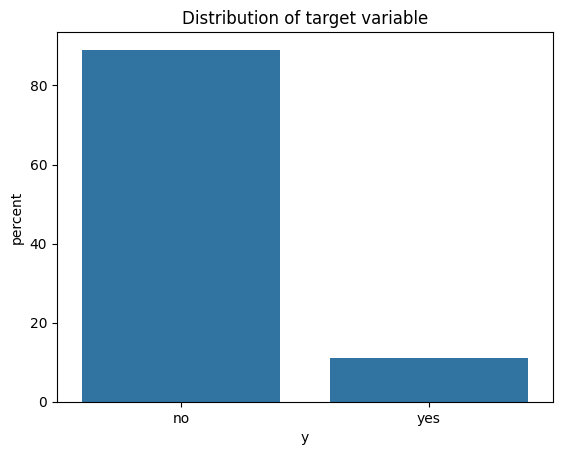

%faliure (no): 10.95%
%sucess (yes): 89.05%


In [146]:
sns.countplot(x='y', data=data, stat='percent')
plt.title('Distribution of target variable')
plt.show()

yes,no = data['y'].value_counts(normalize=True).mul(100).round(2)

print(f'%faliure (no): {no}%\n%sucess (yes): {yes}%')



The target variable is noticably imbalanced. 89% of clients did not subscribe ("no") versus only 11% who did ("yes"). This means accuracy alone is a misleading metric, as a model predicting "no" always would score 89% without learning anything useful. Recall and F1-score are more appropriate here.

### **2.3 Vizualizing numerical & Categorcial Variables**



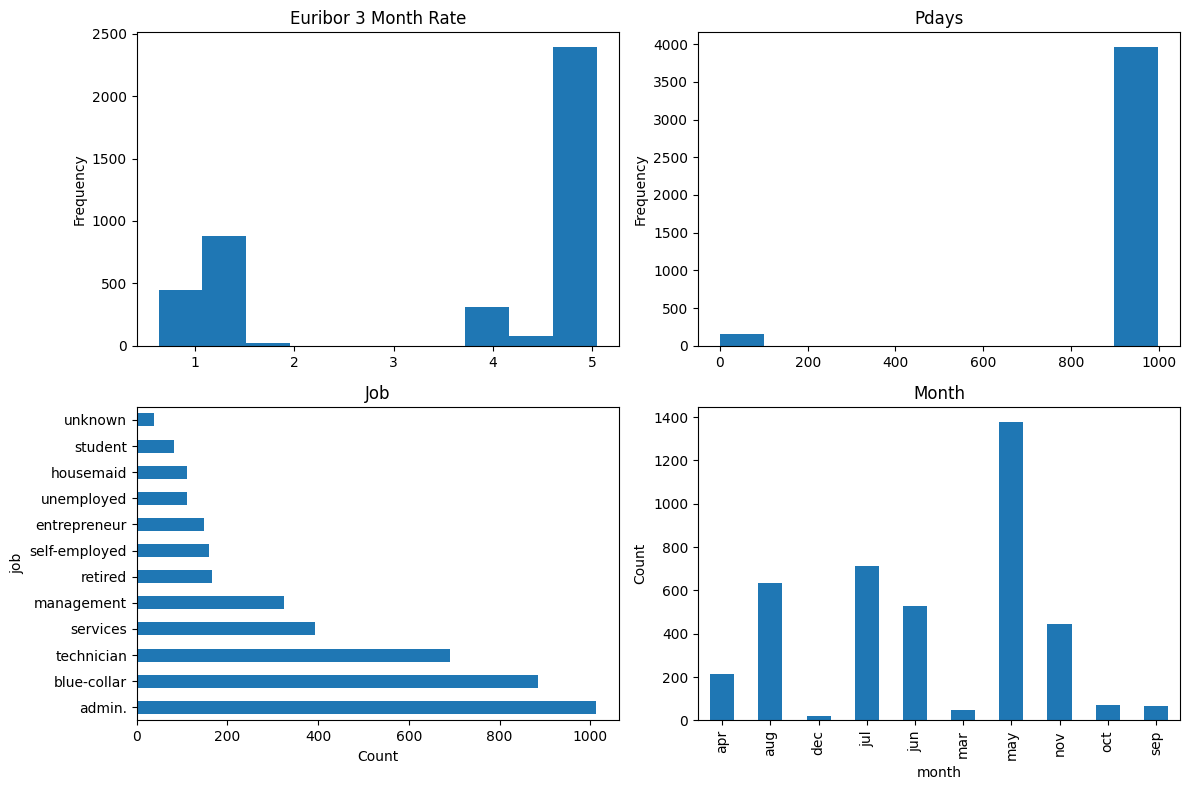

In [147]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Numerical
data['euribor3m'].plot(kind='hist', ax=axes[0, 0], title='Euribor 3 Month Rate')
data['pdays'].plot(kind='hist', ax=axes[0, 1], title='Pdays')

# Categorical
data['job'].value_counts().plot(kind='barh', ax=axes[1, 0], title='Job',xlabel = "Count")
data['month'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], title='Month', ylabel='Count')

plt.tight_layout()
plt.show()

**Euribor 3 Month Rate:** The distribution is bimodal, with most values clustered around 1–1.5 and 4.5–5. This suggests the data spans two distinct economic periods with different interest rate environments.

**Pdays:** Heavily dominated by the value 999, confirming that the vast majority of clients were never contacted in a previous campaign. This reinforces that 999 is a sentinel value, not a real measurement.

**Job:** Admin, blue-collar and technician are the most represented job types, while housemaid, student and unknown are the least common.

**Month:** May dominates contact activity by a large margin, followed by July and August. Notably the months are not in chronological order — this should be fixed for clarity. March, October and September saw very few contacts, suggesting the campaign was not active uniformly throughout the year.

###  **2.4 Missing Values**



In [148]:
print(f"Explicit missing values: {data.isna().sum()}") if data.isna().sum().sum() > 0 else print("No explicit missing values")

unknown_count = data.replace('unknown', pd.NA).isna().sum()
print(f"\nImplicit missing values:\n{unknown_count[unknown_count > 0]}")

No explicit missing values

Implicit missing values:
job           39
marital       11
education    167
default      803
housing      105
loan         105
dtype: int64


No explicit missing values (NaN) were found in the raw dataset. However, several categorical columns contain the string "unknown", which is not random noise but rather indicates that information was either unavailable, never recorded, or deliberately withheld by the client.
Before deciding how to handle these entries, it is worth asking: does the absence of information carry meaning in itself? In many real-world scenarios, the fact that a client did not disclose their job type or credit default status may reflect a behavioural pattern that is predictive of the outcome. Automatically imputing or removing these entries would discard that signal entirely, which is a strong assumption to make without justification.
It is therefore important to distinguish between two types of missingness. Explicit missingness, such as NaN, is typically handled through statistical imputation. Implicit or structural missingness, such as the "unknown" category, may encode systemic or behavioural patterns that deserve to be retained as a separate category rather than filled in.
For this reason, "unknown" values were converted to NaN solely to make missingness visible and quantifiable during exploration. The decision of whether to impute, drop, or retain them as a distinct category will be made per variable in the preprocessing stage, based on the extent of missingness and its likely relationship with the target.

The most affected variable is default (19.5% missing), followed by education (4.1%), housing and loan (2.5%), job (0.9%), and marital (0.3%).

### **2.5 Variables that require special consideration**

`duration` must be excluded from any realistic model. It represents the length of the phone call, which is only known after the call has ended — at which point the outcome is already determined. Including it would constitute target leakage, as discussed in Task 1.

`pdays` cannot be treated as a regular numerical variable. As seen in the histogram, roughly 97% of values are 999, which is a sentinel value meaning the client was never previously contacted. The remaining values represent actual days elapsed. This means the column encodes two fundamentally different things at once and will require special treatment before modelling, such as converting 999 into a binary "never contacted" indicator.


# **3. Data Splitting**

The split must occur immediately after loading and identifying the target variable, before any preprocessing step that learns from the data — including imputation, scaling, encoding, resampling, and feature selection.
If splitting were performed later, any transformation fitted on the full dataset would have already seen the validation and test data. For example, a StandardScaler fitted on the entire dataset would compute the mean and standard deviation using test samples, meaning the model indirectly has information about the test set during training. The same applies to imputation — if the mean of a column is computed on all 4,119 rows, that mean is partially determined by test set values, which would not be available at deployment time. This is data leakage: the model is evaluated under conditions that will never exist in production, producing overly optimistic performance estimates that do not reflect true generalization.


### **3.1 Perform Stratified Splitting.**

First we have to separte the dataset from the outcome variable. We get:

The dataset is separated into:
- X: the feature matrix containing all predictor variables.
- y: the target variable representing subscription outcome

Given the strong class imbalance (~11% "yes"), a random split risks producing holdout sets with a different class distribution than the training set. If the validation or test set ends up with fewer "yes" samples than expected, evaluation metrics like recall and F1 become unreliable. Stratification guarantees that each split preserves the original class distribution (approximetly) ensuring that performance estimates on the validation and test sets are representative of the true data distribution.

- Train: 60%
- Test: 20%
- Validation: 20%




In [149]:
X = data.drop(columns='y')
y = data['y']

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Second split: temp into 50/50 validation and test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Shape:\nTrain:{X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}")

Shape:
Train:(2471, 20)
Validation: (824, 20)
Test: (824, 20)


### **3.2 Verify Stratification**

In [150]:
print(f'Original: \n{round(y.value_counts(normalize=True),5)}')
print(f'\nTrain:\n {round(y_train.value_counts(normalize=True),5)}')
print(f'\nValidation:\n {round(y_val.value_counts(normalize=True),5)}')
print(f'\nTest: \n{round(y_test.value_counts(normalize=True),5)}')

Original: 
y
no     0.89051
yes    0.10949
Name: proportion, dtype: float64

Train:
 y
no     0.89033
yes    0.10967
Name: proportion, dtype: float64

Validation:
 y
no     0.89078
yes    0.10922
Name: proportion, dtype: float64

Test: 
y
no     0.89078
yes    0.10922
Name: proportion, dtype: float64


The output confirms stratification worked correctly — all three sets preserve the original 10.9% minority class proportion. This is exactly what we want.

### **3.3 Split proportions motivation**
A 60/20/20 split was adopted because the dataset contains only 4,119 samples with 11% minority class. Each holdout set must contain enough "yes" samples for reliable evaluation. At 20%, both validation and test sets yield 90 minority class samples, approaching Burkov's ideal of 100. An 80/10/10 split would yield only ~45 "yes" samples per holdout set, below the reliable threshold. A 70/15/15 split yields ~68, better but still short. Since Logistic Regression does not require massive training data, sacrificing 20% training data is justified by the gain in evaluation reliability. The code below showcase this.
**Page 27**

In [151]:
for name, pct in {'80/10/10': 0.1, '70/15/15': 0.15, '60/20/20': 0.2}.items():
    minority = int(len(y) * pct * 0.1095)
    print(f'{name}: {minority} minority class samples per holdout set')

80/10/10: 45 minority class samples per holdout set
70/15/15: 67 minority class samples per holdout set
60/20/20: 90 minority class samples per holdout set



# 4. Managing Missing Values


### 4.1 Missing values & Sentinal numerical values

As identified during the exploratory analysis in Task 2, the dataset contains no explicit missing values but several implicit ones encoded as "unknown", as well as a sentinel value in pdays. Since the split has now been performed, we re-examine missingness exclusively on the training set to ensure no information from the validation or test sets influences any preprocessing decision.

Three types of problematic values were identified:
- explicit missing values (NaN)
- implicit missing values ("unknown")
- sentinel numerical values.

In [152]:
#explicit missing values
print(f"Explicit missing values: {X_train.isna().sum()}") if X_train.isna().sum().sum() > 0 else print("No explicit missing values")

#implicit missing values
unknown_count2 = X_train.replace('unknown', pd.NA).isna().sum()
print(f"\nImplicit missing values:\n{unknown_count2[unknown_count2 > 0]}")

#sentinal values
print(f'\npdays = 999: \n{(X_train["pdays"] == 999).sum()} samples ({(X_train["pdays"] == 999).mean()*100:.1f}%)')


No explicit missing values

Implicit missing values:
job           20
marital        7
education    104
default      492
housing       55
loan          55
dtype: int64

pdays = 999: 
2368 samples (95.8%)


The counts are consistent with what was observed in Task 2, now restricted to the training set.
- `default` remains the most affected variable at ~20% followed by `education`, `housing`, `loan`, `job` and `marital`.
- The pdays sentinel confirms what the histogram already suggested — 95.8% of clients were never previously contacted, meaning this column cannot be treated as a continuous numerical variable, but encodes two fundamentally different states: clients who were previously contacted (4.2%) and clients who were never contacted (95.8%). Treating 999 as a real number and imputing or scaling it alongside genuine day counts would be meaningless. Instead, pdays will be transformed into a binary indicator variable: 0 for never contacted, 1 for previously contacted, effectively replacing the sentinel with an explicit, model-readable signal.

### **4.2 Extent of missingness**
The table below quantifies the extent of missingness for

In [153]:
unknown_count2['pdays'] = (X_train['pdays'] == 999).sum()
pct = (unknown_count2 / len(X_train) * 100).round(2)
pd.DataFrame({'count': unknown_count2[unknown_count2 > 0], '%': pct[pct > 0]})

,count,%
job,20,0.81
marital,7,0.28
education,104,4.21
default,492,19.91
housing,55,2.23
loan,55,2.23
pdays,2368,95.83


### **4.3 Handling missing values**

For categorical variables containing "unknown", the value will be retained as a separate category rather than imputed or removed. This decision is grounded in two considerations.
- First, dropping observations would unnecessarily reduce an already small dataset.
- Second, and more importantly, the reason a client did not disclose information — particularly financial information like default — may itself be predictive of subscription behaviour. Imputing the mode would silently erase this signal. As Burkov notes, the right imputation technique cannot be determined before modelling; retaining "unknown" as a category is the most conservative and transparent choice.

For pdays, the 999 sentinel will be replaced by creating a new binary variable previously_contacted (1 if pdays ≠ 999, 0 otherwise), after which the original pdays column will be dropped. This preserves the structural meaning of the variable without allowing the model to misinterpret 999 as a genuine numerical magnitude.


All transformations that learn from the data — including mode imputation if applied — must be fitted on the training set only and then applied to validation and test sets, as computing statistics on the full dataset would constitute leakage as warned by Burkov.


In [154]:
# Retain 'unknown' as a separate category - no action needed as it is already a string category

# Create binary indicator for pdays
X_train['previously_contacted'] = (X_train['pdays'] != 999).astype(int)
X_val['previously_contacted'] = (X_val['pdays'] != 999).astype(int)
X_test['previously_contacted'] = (X_test['pdays'] != 999).astype(int)

#drop original
X_train = X_train.drop(columns='pdays')
X_val = X_val.drop(columns='pdays')
X_test = X_test.drop(columns='pdays')

previously_contacted distribution:
previously_contacted
0    2368
1     103
Name: count, dtype: int64


### **4.4 Operations that needs to be fitted using the training set only (and why)**

Note: Your strategy should distinguish between “data cleaning” decisions (e.g., correcting inconsistent entries)
and “modeling” decisions (e.g., whether missingness itself may carry predictive information).

Any operation that learns a statistic from the data must be fitted on the training set only and then applied to validation and test sets. In this task, two types of decisions were made:

- **Data cleaning decisions** — The pdays binary transformation is a fixed logical rule (999 or not) that requires no fitting. It is applied identically to all three sets without risk of leakage.
- **Modeling decisions** — Retaining "unknown" as a separate category is also a fixed decision requiring no fitting. However, if mode imputation had been chosen for any variable, the mode would need to be computed on the training set only and then used to fill missing values in validation and test sets. Computing it on the full dataset would allow test set information to influence the imputation value, which constitutes leakage as warned by Burkov.
The distinction matters because data cleaning corrects objective inconsistencies that are independent of the data distribution, while modeling decisions — like imputation — estimate properties of the distribution and must therefore be treated with the same discipline as any other learned transformation.




### **5. Encoding Categorical Values**


### **5.1. Identification and classification of categorical variables in the dataset.**

In [157]:
print("Categorical variables:")
print(X_train.select_dtypes(include='str').columns.tolist())

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


**Ordinal variables (categories with a meaningful order):**
- **`education`** is the only ordinal variable.
- It follows a clear progression: basic.4y → basic.6y → basic.9y → high.school → professional.course → university.degree.
- This ordering reflects increasing levels of educational attainment and should be preserved during encoding using ordinal encoding rather than one-hot encoding.

**Nominal variables (no intrinsic order):**
All nominal — there is no meaningful ranking between their categories:
- **`job`**
- **`marital`**
- **`contact`**
- **`poutcome`**
- **`default`**
- **`housing`**
- **`loan`**
**`month`** and **`day_of_week`** deserve special mention. While they have a natural temporal order, in this context they represent campaign timing patterns rather than a continuous progression. May having more contacts than March does not imply May is "greater than" March in any meaningful sense for subscription prediction. They are therefore treated as nominal.

Lecture material: and Expressiveness). Lecture 4 (Categorical Encoding), Lecture 6 (Linear Models), Lecture 9 (Feature Engineering
1. Identify all categorical variables in the dataset.
2. Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables
(categories with a meaningful order, e.g., education level), and justify your classification.
3. Select and apply an appropriate encoding strategy for each categorical variable.
4. Clearly state which encoders must be fitted on the training set only, and explain why.
5. Analyze how encoding changes:
- the dimensionality of the dataset;
- the interpretability of model coefficients;
- the types of decision boundaries a linear model can represent.


Note: Encoding is not a purely mechanical transformation. Your justification should explicitly connect your encoding
decisions to the assumptions and behavior of Logistic Regression


-------------------


6. Feature Scaling
7. Feature Selection
8. Addressing Class Imbalance
9. Training a Logistic Regression Model
10. Final Discussion